In [1]:
pip install pandas prophet matplotlib

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.1 MB 10.7 MB/s eta 0:00:02
   ------------ --------------------------- 3.7/12.1 MB 10.3 MB/s eta 0:00:01
   ------------------- -------------------- 5.8/12.1 MB 10.2 MB/s eta 0:00:01
   ------------------------- -------------- 7.9/12.1 MB 10.2 MB/s eta 0:00:01
   -------------------------------- ------- 9.7/12.1 MB 10.2 MB/s eta 0:00:01
   -------------------------------------- - 11.8/12.1 MB 10.2 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 10.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 10.6 MB/s eta 0:00:00

   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]

C:\Users\chint\AppData\Local\Temp\ipykernel_17400\2840534526.py:10: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


          ds        y
0 2013-01-01    97235
1 2013-01-02  6949829
2 2013-01-03  6347820
3 2013-01-04  6638954
4 2013-01-05  5951593


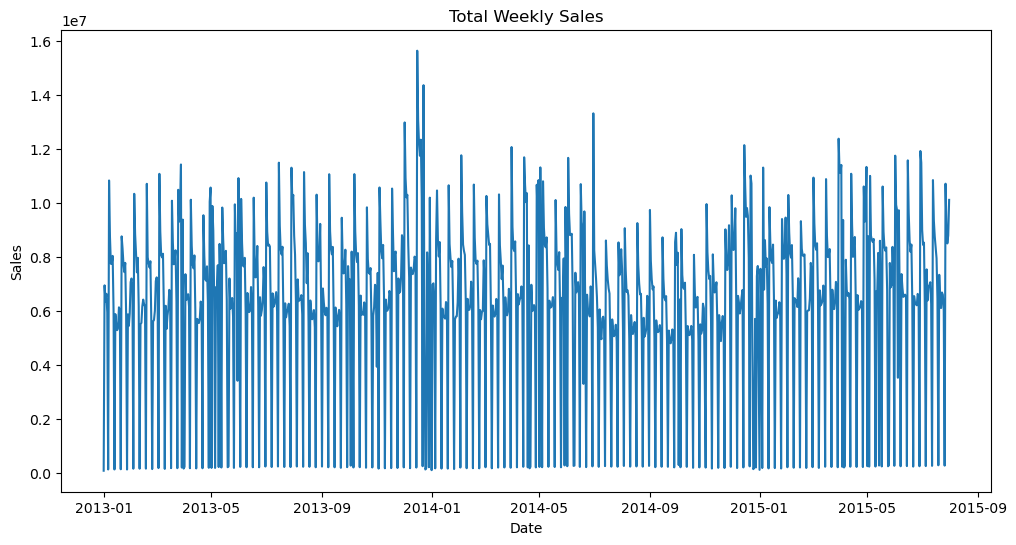

Train Size: 753
Test Size: 189


23:57:58 - cmdstanpy - INFO - Chain [1] start processing
23:57:59 - cmdstanpy - INFO - Chain [1] done processing



Model Performance
MAE : 2708729.7761363294
RMSE: 3330625.436894013


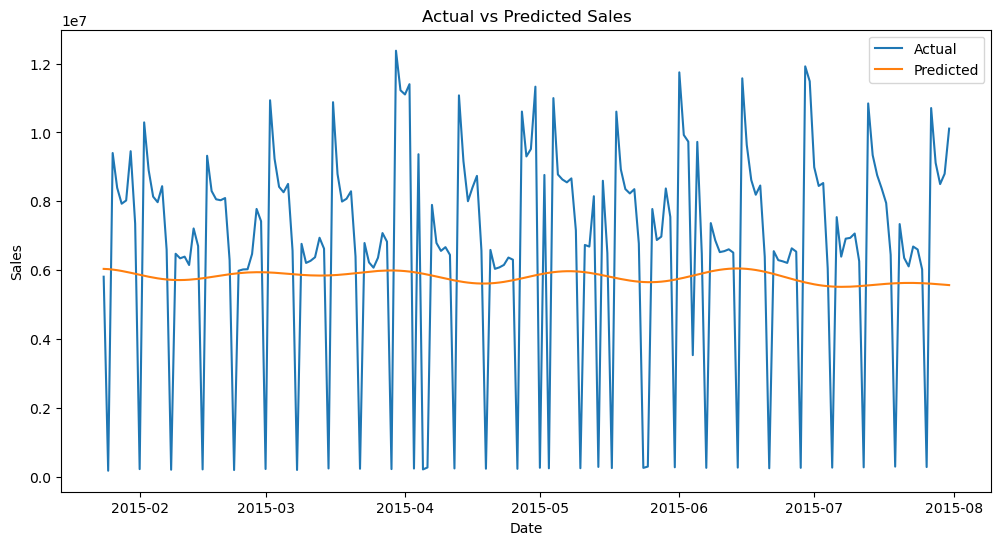

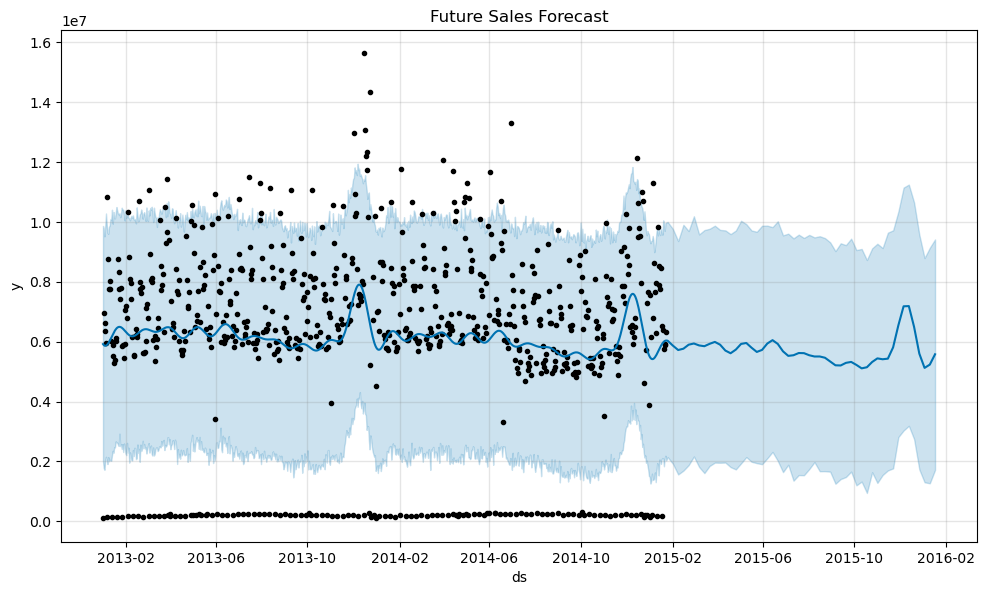

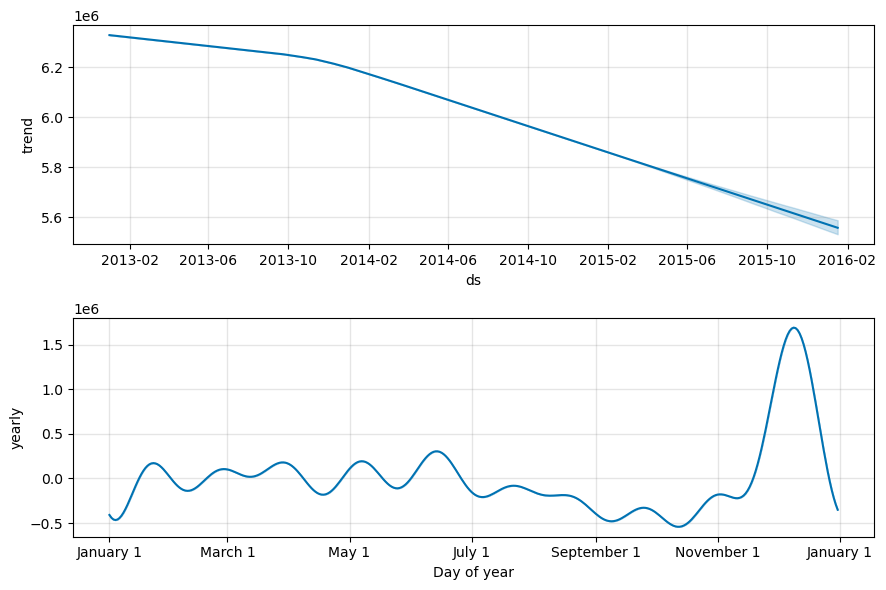


Forecast saved successfully!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ==========================
# LOAD DATA
# ==========================
df = pd.read_csv("train.csv")

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Aggregate sales by date
sales = df.groupby("Date")["Sales"].sum().reset_index()

# Prophet format
sales.columns = ["ds", "y"]

print(sales.head())

# ==========================
# EDA
# ==========================

plt.figure(figsize=(12,6))
plt.plot(sales["ds"], sales["y"])
plt.title("Total Weekly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# ==========================
# TRAIN TEST SPLIT
# ==========================

train_size = int(len(sales)*0.8)

train = sales[:train_size]
test = sales[train_size:]

print("Train Size:", len(train))
print("Test Size:", len(test))

# ==========================
# BUILD MODEL
# ==========================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

# ==========================
# PREDICTION ON TEST DATA
# ==========================

future_test = test[["ds"]]

forecast_test = model.predict(future_test)

predictions = forecast_test["yhat"]

# ==========================
# EVALUATION
# ==========================

mae = mean_absolute_error(test["y"], predictions)

rmse = np.sqrt(
    mean_squared_error(
        test["y"],
        predictions
    )
)

print("\nModel Performance")
print("MAE :", mae)
print("RMSE:", rmse)

# ==========================
# ACTUAL VS PREDICTED
# ==========================

plt.figure(figsize=(12,6))

plt.plot(
    test["ds"],
    test["y"],
    label="Actual"
)

plt.plot(
    test["ds"],
    predictions,
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

# ==========================
# FUTURE FORECAST
# ==========================

future = model.make_future_dataframe(
    periods=52,
    freq="W"
)

forecast = model.predict(future)

# ==========================
# FORECAST GRAPH
# ==========================

fig1 = model.plot(forecast)

plt.title("Future Sales Forecast")

plt.show()

# ==========================
# TREND & SEASONALITY
# ==========================

fig2 = model.plot_components(forecast)

plt.show()

# ==========================
# SAVE RESULTS
# ==========================

forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].to_csv(
    "sales_forecast_results.csv",
    index=False
)

print("\nForecast saved successfully!")